# Quickstart: UCSB CHC CHIRPS analysis, final - dynamical.org Icechunk Zarr

CHIRPS v3 from the UCSB Climate Hazards Center provides daily precipitation over global land from 60°S to 60°N on a 0.05° grid.

This final product begins in 1981 and is transformed into an analysis-ready Zarr store by [dynamical.org](https://dynamical.org).

Dataset documentation: https://dynamical.org/catalog/ucsb-chc-chirps-analysis-final/

In [ ]:
# If running locally, follow README.md for simple dependency installation.
# If using Google Colab, run this cell.
!uv pip install icechunk xarray matplotlib

In [2]:
import icechunk
import xarray as xr

storage = icechunk.s3_storage(
    bucket="dynamical-ucsb-chc-chirps",
    prefix="ucsb-chc-chirps-analysis-final/v0.1.0.icechunk",
    region="us-west-2",
    anonymous=True,
)
repo = icechunk.Repository.open(storage)
ds = xr.open_zarr(repo.readonly_session("main").store, chunks=None)
ds

<xarray.Dataset> Size: 1TB
Dimensions:                (time: 16679, latitude: 2400, longitude: 7200)
Coordinates:
  * time                   (time) datetime64[ns] 133kB 1981-01-01 ... 2026-08-31
  * latitude               (latitude) float64 19kB 59.98 59.93 ... -59.93 -59.98
  * longitude              (longitude) float64 58kB -180.0 -179.9 ... 180.0
    spatial_ref            int64 8B ...
Data variables:
    precipitation_surface  (time, latitude, longitude) float32 1TB ...
Attributes:
    dataset_id:          ucsb-chc-chirps-analysis-final
    dataset_version:     0.1.0
    name:                UCSB CHC CHIRPS analysis, final
    description:         Daily precipitation from the Climate Hazards Center ...
    attribution:         UCSB Climate Hazards Center CHIRPS version 3.0 data ...
    license:             CC-BY-4.0
    spatial_domain:      Global land, 60 degrees north to 60 degrees south
    spatial_resolution:  0.05 degrees (~5km)
    time_domain:         1981-01-01 00:00:00 UTC to Present
    time_resolution:     1 day

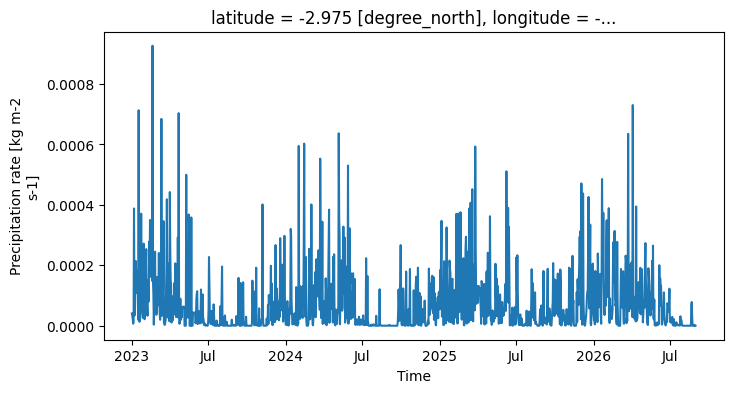

In [3]:
(
    ds["precipitation_surface"]
    .sel(latitude=-3, longitude=-60, method="nearest")
    .sel(time=slice("2023", "2026"))
    .plot(size=4, aspect=2)
)